<a href="https://colab.research.google.com/github/aabyyaann/UAS-ML/blob/main/UAS_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow optuna mlflow lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 3.9 MB/s eta 0:00:00
   ━━━

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import optuna
import mlflow
import mlflow.tensorflow

from lime.lime_tabular import LimeTabularExplainer

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
Num GPUs Available: 0


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to", SEED)

Seed set to 42


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_PATH = "/content/drive/MyDrive/Midterm ML/midterm-regresi-dataset.csv"

print("Dataset path:", DATA_PATH)
print("Exists:", os.path.exists(DATA_PATH))

Dataset path: /content/drive/MyDrive/Midterm ML/midterm-regresi-dataset.csv
Exists: True


In [6]:
df = pd.read_csv(DATA_PATH, header=None)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (515345, 91)


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [7]:
target_col = "Year"
feature_cols = [f"Feature_{i}" for i in range(1, df.shape[1])]

df.columns = [target_col] + feature_cols

print("Total columns:", len(df.columns))
df.head()

Total columns: 91


,Year,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_81,Feature_82,Feature_83,Feature_84,Feature_85,Feature_86,Feature_87,Feature_88,Feature_89,Feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Year        515345 non-null  int64  
 1   Feature_1   515345 non-null  float64
 2   Feature_2   515345 non-null  float64
 3   Feature_3   515345 non-null  float64
 4   Feature_4   515345 non-null  float64
 5   Feature_5   515345 non-null  float64
 6   Feature_6   515345 non-null  float64
 7   Feature_7   515345 non-null  float64
 8   Feature_8   515345 non-null  float64
 9   Feature_9   515345 non-null  float64
 10  Feature_10  515345 non-null  float64
 11  Feature_11  515345 non-null  float64
 12  Feature_12  515345 non-null  float64
 13  Feature_13  515345 non-null  float64
 14  Feature_14  515345 non-null  float64
 15  Feature_15  515345 non-null  float64
 16  Feature_16  515345 non-null  float64
 17  Feature_17  515345 non-null  float64
 18  Feature_18  515345 non-null  float64
 19  Fe

In [9]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary.head(20)

,0
Year,0
Feature_1,0
Feature_2,0
Feature_3,0
Feature_4,0
Feature_5,0
Feature_6,0
Feature_7,0
Feature_8,0
Feature_9,0


In [10]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 214


In [11]:
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


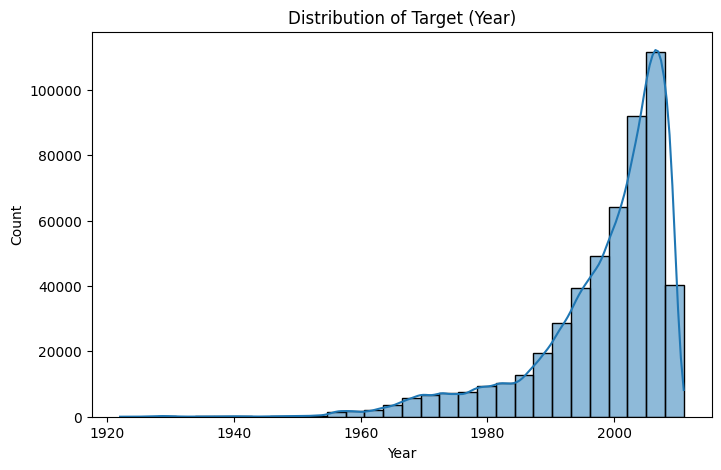

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df[target_col], bins=30, kde=True)
plt.title("Distribution of Target (Year)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [13]:
df[target_col].describe()

,Year
count,515345.000000
mean,1998.397082
std,10.931046
min,1922.000000
25%,1994.000000
50%,2002.000000
75%,2006.000000
max,2011.000000


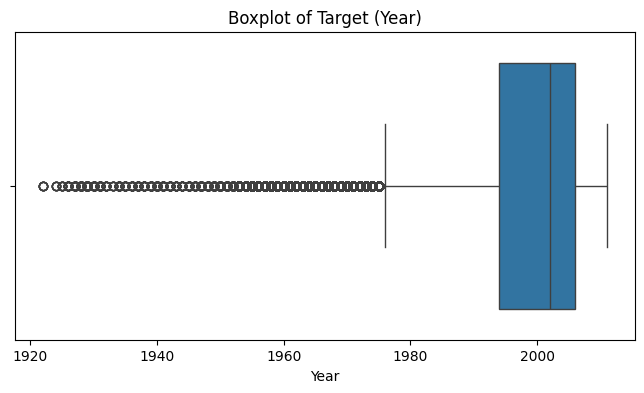

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df[target_col])
plt.title("Boxplot of Target (Year)")
plt.show()

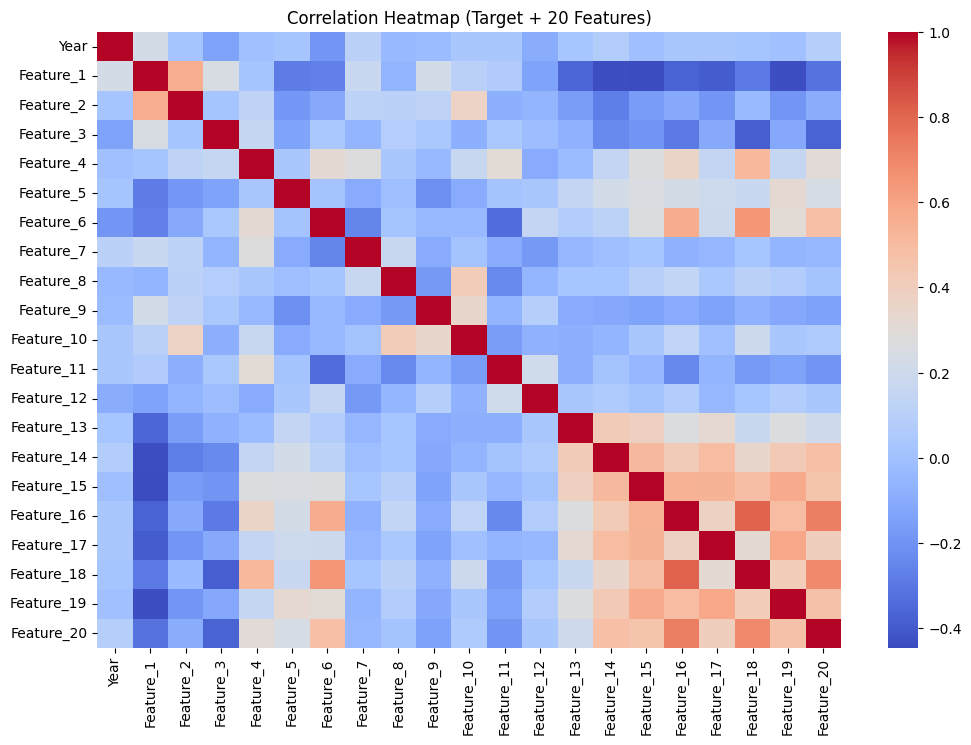

In [15]:
subset_cols = [target_col] + feature_cols[:20]
corr_matrix = df[subset_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Heatmap (Target + 20 Features)")
plt.show()

In [16]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (515345, 90)
y shape: (515345,)


In [17]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED
)

print("Train full shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Train full shape: (412276, 90)
Test shape: (103069, 90)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (412276, 90)
Scaled test shape: (103069, 90)


In [19]:
K_BEST = 60

selector = SelectKBest(score_func=f_regression, k=min(K_BEST, X_train_scaled.shape[1]))
X_train_kbest = selector.fit_transform(X_train_scaled, y_train_full)
X_test_kbest = selector.transform(X_test_scaled)

selected_mask = selector.get_support()
selected_feature_names = X.columns[selected_mask].tolist()

print("Original features:", X_train_scaled.shape[1])
print("Selected features:", X_train_kbest.shape[1])
print("First selected features:", selected_feature_names[:10])

Original features: 90
Selected features: 60
First selected features: ['Feature_1', 'Feature_3', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_14', 'Feature_16']


In [20]:
pca = PCA(n_components=0.95, random_state=SEED)

X_train_pca = pca.fit_transform(X_train_kbest)
X_test_pca = pca.transform(X_test_kbest)

print("Shape after PCA (train):", X_train_pca.shape)
print("Shape after PCA (test):", X_test_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

Shape after PCA (train): (412276, 47)
Shape after PCA (test): (103069, 47)
Explained variance ratio sum: 0.9546225690543758


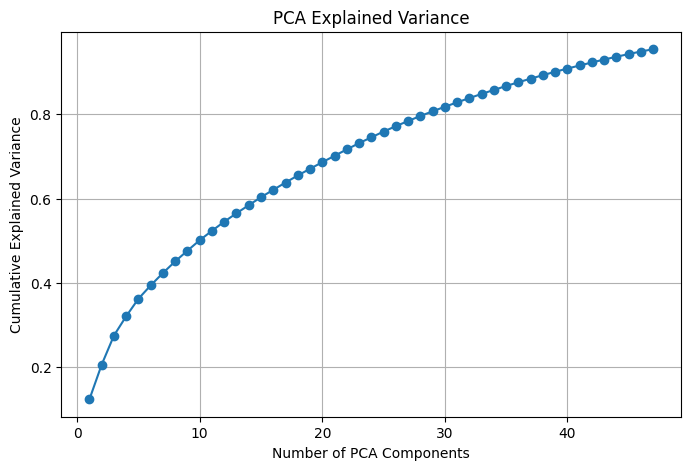

In [21]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [22]:
input_dim = X_train_pca.shape[1]
print("Final input dimension for model:", input_dim)

Final input dimension for model: 47


In [23]:
def build_regression_model(input_dim, units1=128, units2=64, dropout1=0.2, dropout2=0.2, lr=1e-3):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(units1, activation="relu"),
        BatchNormalization(),
        Dropout(dropout1),

        Dense(units2, activation="relu"),
        BatchNormalization(),
        Dropout(dropout2),

        Dense(1, activation="linear")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )
    return model

In [24]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [25]:
baseline_model = build_regression_model(
    input_dim=input_dim,
    units1=128,
    units2=64,
    dropout1=0.2,
    dropout2=0.2,
    lr=1e-3
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [26]:
history_baseline = baseline_model.fit(
    X_train_pca,
    y_train_full,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 3660281.5000 - mae: 1911.6174 - val_loss: 3048279.0000 - val_mae: 1745.8911 - learning_rate: 0.0010
Epoch 2/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 2203713.2500 - mae: 1474.5344 - val_loss: 1369558.2500 - val_mae: 1170.2068 - learning_rate: 0.0010
Epoch 3/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 758479.9375 - mae: 847.6818 - val_loss: 285496.1875 - val_mae: 534.1626 - learning_rate: 0.0010
Epoch 4/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 114416.7500 - mae: 298.5439 - val_loss: 12807.7881 - val_mae: 112.5120 - learning_rate: 0.0010
Epoch 5/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 17950.6445 - mae: 106.1400 - val_loss: 252.0182 - val_mae: 13.4853 - learning_rate: 0.0010
Epoch 6/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 15805.6641 - mae: 100.2778 - val_loss: 161.7979 - val_mae: 10.6887 - learning_rate: 0.0010
Epoch 7/30
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step

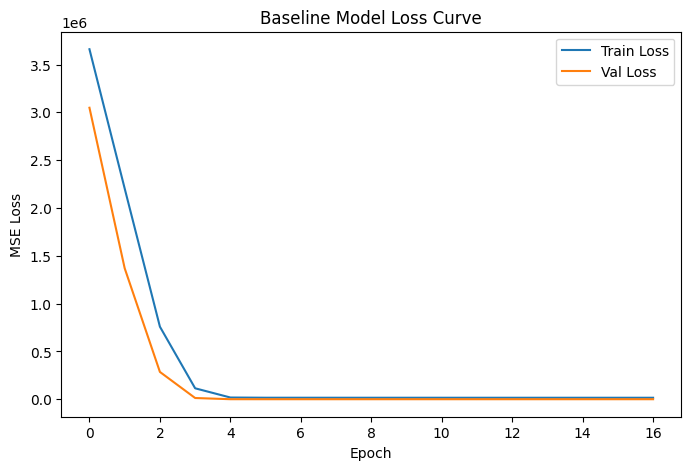

In [27]:
plt.figure(figsize=(8,5))
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [28]:
y_pred_baseline = baseline_model.predict(X_test_pca, verbose=0).flatten()

print("Prediction sample:", y_pred_baseline[:5])

Prediction sample: [1995.11   1979.836  1986.9647 1985.3866 1983.1979]


In [29]:
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("=== BASELINE MODEL ===")
print("MSE  :", baseline_mse)
print("RMSE :", baseline_rmse)
print("MAE  :", baseline_mae)
print("R2   :", baseline_r2)

=== BASELINE MODEL ===
MSE  : 125.24371337890625
RMSE : 11.191233773758203
MAE  : 9.305906295776367
R2   : -0.052335381507873535


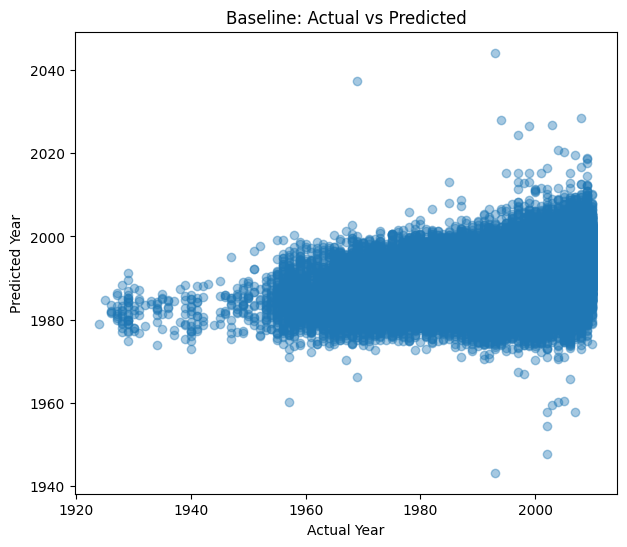

In [30]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_baseline, alpha=0.4)
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.title("Baseline: Actual vs Predicted")
plt.show()

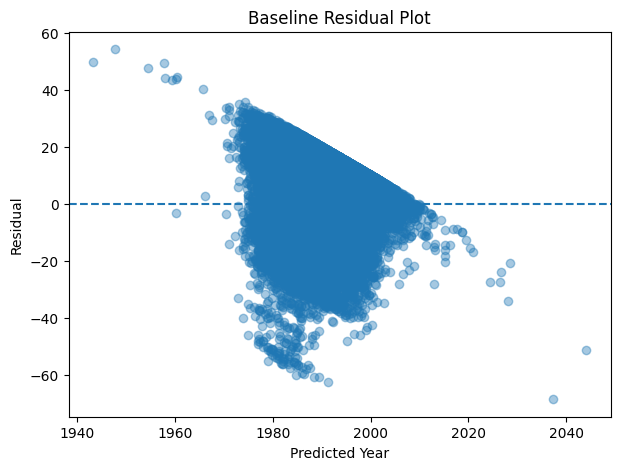

In [31]:
baseline_residuals = y_test - y_pred_baseline

plt.figure(figsize=(7,5))
plt.scatter(y_pred_baseline, baseline_residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Year")
plt.ylabel("Residual")
plt.title("Baseline Residual Plot")
plt.show()

In [32]:
def objective(trial):
    units1 = trial.suggest_categorical("units1", [64, 128, 256])
    units2 = trial.suggest_categorical("units2", [32, 64, 128])
    dropout1 = trial.suggest_float("dropout1", 0.1, 0.4)
    dropout2 = trial.suggest_float("dropout2", 0.1, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256])

    model = build_regression_model(
        input_dim=input_dim,
        units1=units1,
        units2=units2,
        dropout1=dropout1,
        dropout2=dropout2,
        lr=lr
    )

    history = model.fit(
        X_train_pca,
        y_train_full,
        validation_split=0.2,
        epochs=12,
        batch_size=batch_size,
        verbose=0,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        ]
    )

    best_val_loss = min(history.history["val_loss"])
    return best_val_loss

In [33]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("Best trial:")
print(study.best_trial.number)
print("Best params:")
print(study.best_params)
print("Best val loss:", study.best_value)

[I 2026-06-22 06:11:53,361] A new study created in memory with name: no-name-c940cfa2-9b11-4b65-8512-9377a5167606


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-22 06:13:30,095] Trial 0 finished with value: 355146.71875 and parameters: {'units1': 64, 'units2': 128, 'dropout1': 0.3690155711113289, 'dropout2': 0.39466923984103863, 'lr': 0.00019181241067686824, 'batch_size': 256}. Best is trial 0 with value: 355146.71875.
[I 2026-06-22 06:15:06,881] Trial 1 finished with value: 97.73177337646484 and parameters: {'units1': 128, 'units2': 64, 'dropout1': 0.1569206256672032, 'dropout2': 0.10028559813591394, 'lr': 0.0011022433310935702, 'batch_size': 256}. Best is trial 1 with value: 97.73177337646484.
[I 2026-06-22 06:16:12,070] Trial 2 finished with value: 466.6597900390625 and parameters: {'units1': 128, 'units2': 64, 'dropout1': 0.25781636841751865, 'dropout2': 0.3960883645870906, 'lr': 0.0013030081873486152, 'batch_size': 256}. Best is trial 1 with value: 97.73177337646484.
[I 2026-06-22 06:17:37,691] Trial 3 finished with value: 2919196.5 and parameters: {'units1': 128, 'units2': 32, 'dropout1': 0.33718899090643495, 'dropout2': 0.143

In [34]:
best_params = study.best_params
best_params

{'units1': 128,
 'units2': 64,
 'dropout1': 0.1569206256672032,
 'dropout2': 0.10028559813591394,
 'lr': 0.0011022433310935702,
 'batch_size': 256}

In [35]:
best_model = build_regression_model(
    input_dim=input_dim,
    units1=best_params["units1"],
    units2=best_params["units2"],
    dropout1=best_params["dropout1"],
    dropout2=best_params["dropout2"],
    lr=best_params["lr"]
)

best_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [36]:
history_best = best_model.fit(
    X_train_pca,
    y_train_full,
    validation_split=0.2,
    epochs=35,
    batch_size=best_params["batch_size"],
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/35
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 3590893.5000 - mae: 1892.6710 - val_loss: 2866257.2500 - val_mae: 1692.9584 - learning_rate: 0.0011
Epoch 2/35
1283/1289 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2393151.5904 - mae: 1540.1847
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005511216586455703.
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1924758.1250 - mae: 1373.1620 - val_loss: 1045090.8125 - val_mae: 1022.2220 - learning_rate: 0.0011
Epoch 3/35
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 721207.6875 - mae: 841.2710 - val_loss: 438135.0000 - val_mae: 661.8060 - learning_rate: 5.5112e-04
Epoch 4/35
1281/1289 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 341234.6557 - mae: 576.1583
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00027556082932278514.
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 256070.8125 - mae: 492.7268 - val_loss: 111308.3750 - val_mae: 333.4199 - learning_rate: 5.5112e-04
Epoch 5/35
1289/1289 ━━━━━━━━━━━━━━━━━

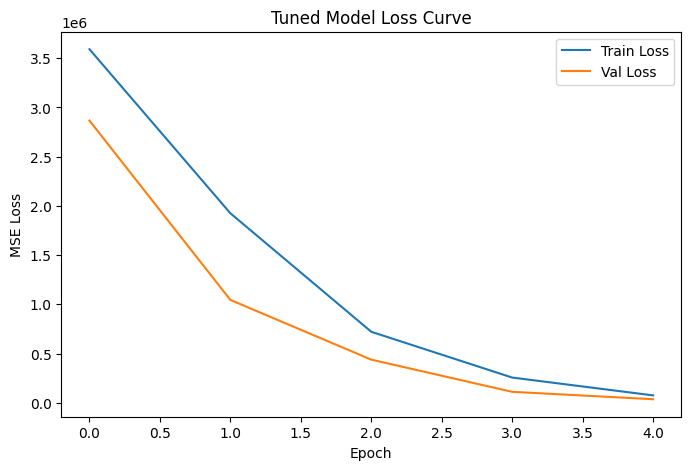

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history_best.history["loss"], label="Train Loss")
plt.plot(history_best.history["val_loss"], label="Val Loss")
plt.title("Tuned Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [38]:
y_pred_best = best_model.predict(X_test_pca, verbose=0).flatten()
print("Prediction sample:", y_pred_best[:5])

Prediction sample: [314.3693 306.6798 299.8097 307.6102 297.0325]


In [39]:
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("=== TUNED MODEL ===")
print("MSE  :", mse_best)
print("RMSE :", rmse_best)
print("MAE  :", mae_best)
print("R2   :", r2_best)

=== TUNED MODEL ===
MSE  : 2866163.75
RMSE : 1692.9748226125514
MAE  : 1692.930419921875
R2   : -24081.37109375


In [40]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "MSE": [baseline_mse, mse_best],
    "RMSE": [baseline_rmse, rmse_best],
    "MAE": [baseline_mae, mae_best],
    "R2": [baseline_r2, r2_best]
})

comparison_df

,Model,MSE,RMSE,MAE,R2
0,Baseline,1.252437e+02,11.191234,9.305906,-0.052335
1,Tuned,2.866164e+06,1692.974823,1692.930420,-24081.371094


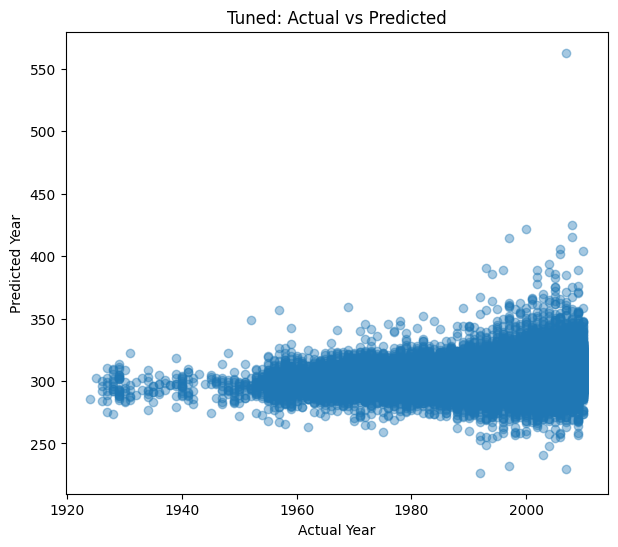

In [41]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.title("Tuned: Actual vs Predicted")
plt.show()

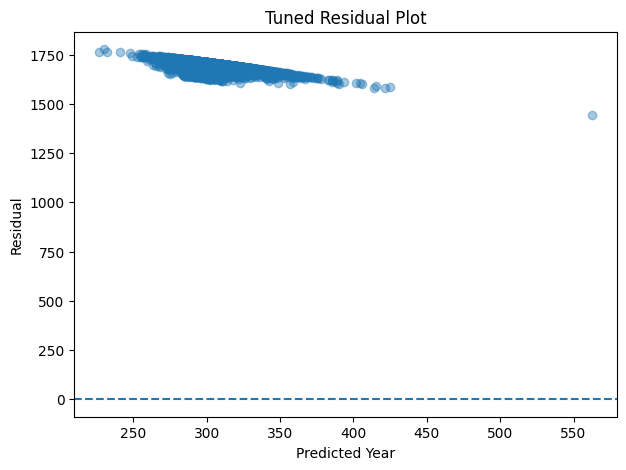

In [42]:
residuals_best = y_test - y_pred_best

plt.figure(figsize=(7,5))
plt.scatter(y_pred_best, residuals_best, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Year")
plt.ylabel("Residual")
plt.title("Tuned Residual Plot")
plt.show()

In [43]:
mlflow.set_experiment("UAS_Song_Year_Regression")
print("MLflow experiment set.")

2026/06/22 06:30:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/22 06:30:49 INFO mlflow.store.db.utils: Updating database tables
2026/06/22 06:30:52 INFO mlflow.tracking.fluent: Experiment with name 'UAS_Song_Year_Regression' does not exist. Creating a new experiment.


MLflow experiment set.


In [44]:
with mlflow.start_run(run_name="best_regression_model"):
    # preprocessing info
    mlflow.log_param("k_best", K_BEST)
    mlflow.log_param("pca_components", X_train_pca.shape[1])

    # best params
    for k, v in best_params.items():
        mlflow.log_param(k, v)

    # metrics
    mlflow.log_metric("baseline_rmse", baseline_rmse)
    mlflow.log_metric("baseline_mae", baseline_mae)
    mlflow.log_metric("baseline_r2", baseline_r2)

    mlflow.log_metric("rmse_best", rmse_best)
    mlflow.log_metric("mae_best", mae_best)
    mlflow.log_metric("r2_best", r2_best)

    # save model artifact
    mlflow.tensorflow.log_model(best_model, artifact_path="best_model")

print("MLflow logging done.")

2026/06/22 06:30:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 06:30:53 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLflow logging done.


In [45]:
explainer = LimeTabularExplainer(
    training_data=X_train_pca,
    mode="regression",
    feature_names=[f"PC{i+1}" for i in range(X_train_pca.shape[1])]
)

print("LIME explainer created.")

LIME explainer created.


In [46]:
exp = explainer.explain_instance(
    data_row=X_test_pca[0],
    predict_fn=lambda x: best_model.predict(x, verbose=0).flatten(),
    num_features=min(10, X_test_pca.shape[1])
)

print("LIME explanation for first test sample:")
for item in exp.as_list():
    print(item)

LIME explanation for first test sample:
('PC7 <= -0.69', -2.940102949855912)
('-1.82 < PC1 <= -0.61', 2.537510853951957)
('PC6 <= -0.69', -2.4203301521771854)
('PC14 <= -0.53', 2.3508393192468025)
('PC22 > 0.49', 2.0828811449514624)
('PC2 <= -0.94', -2.059892955380837)
('PC9 <= -0.67', 1.919913591086852)
('PC24 <= -0.47', 1.9088681142826738)
('PC42 <= -0.33', 1.6385512877562471)
('PC41 > 0.35', -1.4387573006713021)


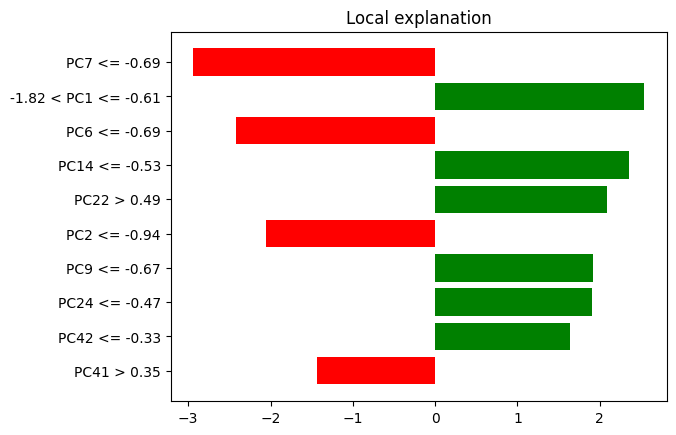

In [47]:
fig = exp.as_pyplot_figure()
plt.show()

In [48]:
best_model.save("song_year_regression_model.keras")
print("Model saved.")

Model saved.


In [49]:
result_df = pd.DataFrame({
    "Metric": ["Baseline_MSE", "Baseline_RMSE", "Baseline_MAE", "Baseline_R2",
               "Tuned_MSE", "Tuned_RMSE", "Tuned_MAE", "Tuned_R2"],
    "Value": [baseline_mse, baseline_rmse, baseline_mae, baseline_r2,
              mse_best, rmse_best, mae_best, r2_best]
})

result_df.to_csv("regression_metrics.csv", index=False)
result_df

,Metric,Value
0,Baseline_MSE,1.252437e+02
1,Baseline_RMSE,1.119123e+01
2,Baseline_MAE,9.305906e+00
3,Baseline_R2,-5.233538e-02
4,Tuned_MSE,2.866164e+06
5,Tuned_RMSE,1.692975e+03
6,Tuned_MAE,1.692930e+03
7,Tuned_R2,-2.408137e+04


In [50]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(selector, "selectkbest.pkl")
joblib.dump(pca, "pca.pkl")

print("Scaler, SelectKBest, and PCA saved.")

Scaler, SelectKBest, and PCA saved.


In [51]:
print("===== FINAL SUMMARY =====")
print("Dataset shape:", df.shape)
print("Train shape after PCA:", X_train_pca.shape)
print("Test shape after PCA:", X_test_pca.shape)
print()
print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)
print("Baseline R2  :", baseline_r2)
print()
print("Best RMSE:", rmse_best)
print("Best MAE :", mae_best)
print("Best R2  :", r2_best)

===== FINAL SUMMARY =====
Dataset shape: (515345, 91)
Train shape after PCA: (412276, 47)
Test shape after PCA: (103069, 47)

Baseline RMSE: 11.191233773758203
Baseline MAE : 9.305906295776367
Baseline R2  : -0.052335381507873535

Best RMSE: 1692.9748226125514
Best MAE : 1692.930419921875
Best R2  : -24081.37109375


In [52]:
print("Notebook name target: UAS_Regresi.ipynb")
print("Before saving to GitHub:")
print("1. Runtime -> Restart and run all (optional kalau mau final bersih)")
print("2. Jangan pakai show_in_notebook()")
print("3. Save a copy in GitHub dengan nama: UAS_Regresi.ipynb")

Notebook name target: UAS_Regresi.ipynb
Before saving to GitHub:
1. Runtime -> Restart and run all (optional kalau mau final bersih)
2. Jangan pakai show_in_notebook()
3. Save a copy in GitHub dengan nama: UAS_Regresi.ipynb
